# Multi-Task Omics — `multibench` end-to-end tutorial

This notebook walks the complete user story for the **`multibench`** wrapper around
the scMultiBench integration methods:

```
inputs_for  →  params_for  →  run  →  evaluate  →  plot
 (data)        (tuning)      (method)  (metrics)   (figure)
```

Everything here is **run-verified** on one reference dataset, **D11**
(CITE-seq PBMC, 2,864 cells, RNA + ADT). All **14** methods that support the
`vertical [rna, adt]` scenario were executed end-to-end on it.

> **Why D11?** Integration methods are defined by the scenario they solve, so no
> single dataset can exercise all 40 methods. D11 is the largest set of methods
> (14) that share one dataset, and at 2,864 cells it is small enough that you can
> actually re-run this notebook.

## 0. Setup

Run this notebook in the driver environment (`scmbench_eval`).

In [1]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import multibench as mtb

print("multibench", mtb.__version__)

from pathlib import Path
# verified sweep results shipped next to this notebook
RESULTS = Path("results")

multibench 0.1.0


### Environments

Each method runs in its **own conda environment** (they need mutually incompatible
framework versions). The package maps method → env for you, and ships lockfiles so
a fresh machine can rebuild them.

```bash
multibench env doctor          # what is needed / missing
multibench env install --run   # build everything from lockfiles
```

In [2]:
DATASET  = "D11"
CATEGORY = "vertical"
MODALITIES = ["rna", "adt"]

METHODS = ["Concerto", "MOFA2", "Matilda", "Multigrate", "Seurat_WNN", "UINMF",
           "VIMCCA", "moETM", "scMDC", "scMM", "scMSI", "scMoMaT", "sciPENN", "totalVI"]

pd.DataFrame([{"method": m, "env": mtb.env.group_for(m)} for m in METHODS])

,method,env
0,Concerto,scmb_concerto
1,MOFA2,MOFA2_env
2,Matilda,matilda
3,Multigrate,scmb_multigrate2
4,Seurat_WNN,scmb_seurat5
5,UINMF,scmb_r
6,VIMCCA,scmb_vimcca
7,moETM,env_moETM
8,scMDC,scmb_scmdc
9,scMM,scmb_scmm2


## 1. Discovery — which methods fit my data?

`find_methods` filters the registry; `method_info` describes one method.

In [3]:
vertical_rna_adt = mtb.find_methods(category="vertical", modalities=["rna", "adt"])
print(len(vertical_rna_adt), "methods support vertical [rna, adt]")
print(sorted(vertical_rna_adt))

14 methods support vertical [rna, adt]
['Concerto', 'MOFA2', 'Matilda', 'Multigrate', 'Seurat_WNN', 'UINMF', 'VIMCCA', 'moETM', 'scMDC', 'scMM', 'scMSI', 'scMoMaT', 'sciPENN', 'totalVI']


In [4]:
info = mtb.method_info("Matilda")
{k: info[k] for k in ("id", "language", "categories", "tasks", "env", "status")}

{'id': 'Matilda',
 'language': 'python',
 'categories': ['vertical'],
 'tasks': ['classification', 'clustering', 'dimension_reduction'],
 'env': 'matilda',
 'status': 'verified'}

## 2. Data — resolve the inputs

`inputs_for` maps a dataset + method + scenario to the concrete files that method
expects. `check=True` verifies they exist, so you fail fast instead of mid-run.

In [5]:
inputs = mtb.inputs_for(DATASET, "Matilda", CATEGORY,
                       modalities=MODALITIES, check=True)
inputs

{'rna': '/media/disk2/Sichang/scmbench_pkg/data/D11/rna.h5',
 'adt': '/media/disk2/Sichang/scmbench_pkg/data/D11/adt.h5',
 'cty': '/media/disk2/Sichang/scmbench_pkg/data/D11/cty.csv'}

In [6]:
# cell-type labels used later for the metrics
mtb.labels_for(DATASET)

{'cty': '/media/disk2/Sichang/scmbench_pkg/data/D11/cty.csv'}

## 3. Parameters — what can I actually tune?

`params_for` reports two things:

* **`defaults`** — parameters the wrapper passes on every run. Override them with
  `run(..., params={...})`.
* **`tunable`** — parameters the **upstream script** accepts on its command line,
  with their upstream defaults.

> **An honest limitation.** Only the parameters a method exposes on its CLI can be
> tuned, because this project never modifies the upstream method scripts. Of the 14
> methods here, **5** expose hyperparameters; the other **9 hardcode them** and
> report `tunable: {}`. That is a property of the methods, not a gap in the wrapper.

In [7]:
p = mtb.params_for("Matilda", CATEGORY, MODALITIES)
print("defaults:", p["defaults"])
print("tunable :", list(p["tunable"])[:10])

defaults: {'epochs': 30, 'seed': 1, 'device': 'auto'}
tunable : ['augmentation', 'batch_size', 'device', 'epochs', 'hidden_adt', 'hidden_atac', 'hidden_rna', 'lr', 'seed', 'z_dim']


In [8]:
rows = []
for m in METHODS:
    q = mtb.params_for(m, CATEGORY, MODALITIES)
    rows.append({"method": m, "n_tunable": len(q["tunable"]),
                 "defaults": q["defaults"],
                 "example_tunable": ", ".join(sorted(q["tunable"])[:4]) or "(none - hardcoded upstream)"})
pd.DataFrame(rows).sort_values("n_tunable", ascending=False).reset_index(drop=True)

,method,n_tunable,defaults,example_tunable
0,scMDC,24,{'nbatch': 1},"batch_size, cutoff, data_file, device"
1,scMM,19,"{'model': 'rna_protein', 'no_cuda': True}","analytics, batch_size, deterministic_warmup, e..."
2,Matilda,10,"{'epochs': 30, 'seed': 1, 'device': 'auto'}","augmentation, batch_size, device, epochs"
3,Multigrate,3,"{'epochs': 200, 'bs': 256, 'lr': 0.001}","bs, epochs, lr"
4,sciPENN,1,{},seed
5,Concerto,0,{},(none - hardcoded upstream)
6,MOFA2,0,{},(none - hardcoded upstream)
7,Seurat_WNN,0,{},(none - hardcoded upstream)
8,UINMF,0,{},(none - hardcoded upstream)
9,VIMCCA,0,{},(none - hardcoded upstream)


## 4. Run a method

`run` builds the command, executes it inside the method's own conda env, and loads
the output back. **Method scripts are never modified.**

We pass `params={"epochs": 5}` to keep this demo quick — that is the tuning API from
the previous section doing real work.

In [9]:
res = mtb.run(method="Matilda", category=CATEGORY, inputs=inputs,
              out_dir="/tmp/tutorial/Matilda_D11",
              params={"epochs": 5})

emb = res.output
print("embedding:", emb.shape)

embedding: (2864, 100)


### ⚠️ Not every method returns an embedding

Check `output.kind` before you compute embedding-based metrics. Of these 14
methods, **12 return `embedding`** and **2 return `graph`**:

| method | kind | what it writes |
|---|---|---|
| `Seurat_WNN` | `graph` | a weighted nearest-neighbour graph — **no embedding at all** |
| `scMoMaT` | `graph` | KNN indices/distances; a 2-D UMAP lives in `extra_outputs` |

Running clustering metrics on a KNN **index matrix** silently produces garbage
(ARI ≈ 0), so branch on `kind` rather than assuming.

In [10]:
from multibench.engine import registry

rows = []
for m in METHODS:
    v = registry.get(m).select(CATEGORY, set(MODALITIES))
    rows.append({"method": m, "kind": v.output.kind, "file": v.output.file,
                 "extra": ", ".join(f"{o.kind}:{o.file}" for o in v.extra_outputs) or "-"})
pd.DataFrame(rows).sort_values("kind").reset_index(drop=True)

,method,kind,file,extra
0,Concerto,embedding,embedding.h5,-
1,MOFA2,embedding,embedding.h5,-
2,Matilda,embedding,embedding.h5,labels:predict.csv
3,Multigrate,embedding,embedding.h5,-
4,UINMF,embedding,embedding.h5,-
5,VIMCCA,embedding,embedding.h5,-
6,moETM,embedding,embedding.h5,-
7,scMDC,embedding,embedding.h5,-
8,scMM,embedding,embedding.h5,-
9,scMSI,embedding,embedding.h5,-


## 5. Evaluate — scIB metrics

`evaluate` derives an optimal-resolution Leiden clustering from the embedding and
scores it against the true cell types (the standard scIB protocol). Pass the label
vector in the embedding's **cell order**.

In [11]:
import numpy as np

labels = pd.read_csv(mtb.labels_for(DATASET)["cty"])
labels = labels["x"].to_numpy() if "x" in labels.columns else labels.iloc[:, -1].to_numpy()

scores = mtb.evaluate(emb, category=CATEGORY, task="clustering", labels=labels)
scores

/media/disk2/Sichang/.conda/envs/scmbench_eval/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cluster for cluster_0.2 with leiden
Cluster for cluster_0.4 with leiden
Cluster for cluster_0.6 with leiden


Cluster for cluster_0.8 with leiden
Cluster for cluster_1.0 with leiden
Cluster for cluster_1.2 with leiden


Cluster for cluster_1.4 with leiden
Cluster for cluster_1.6 with leiden
Cluster for cluster_1.8 with leiden


Cluster for cluster_2.0 with leiden


,Value
ARI,0.873072
NMI,0.869760
ASW,0.597756
iASW,0.581653
iF1,0.817894
cLISI,0.996140


> All six clustering metrics compute here, including the isolated-label
> scores `iASW` / `iF1` (this benchmark scores every label, so they exist
> even on a single-batch dataset like D11). Batch metrics are absent
> because D11 has a single batch - that is correct, not missing data.

## 6. Plot

`to_long` reshapes the scores for plotting; `plot.bubble` renders the comparison
figure used throughout the benchmark.

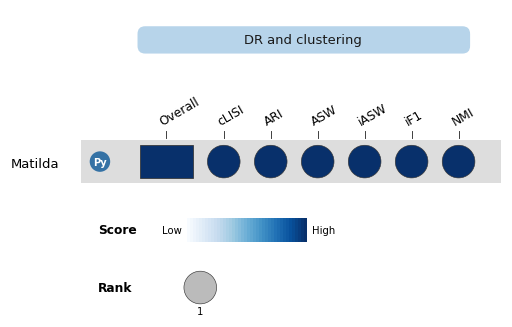

In [12]:
long = mtb.to_long(scores, method="Matilda", dataset=DATASET, category=CATEGORY)
fig = mtb.plot.bubble(long)
fig.set_dpi(110)
display(fig)

## 7. Comparing all 14 methods

Running every method takes hours (sciPENN 143 s → scMSI 2.3 h), so we load the
verified results from the full sweep and plot them together.

In [13]:
summary = pd.read_csv(RESULTS / "summary_D11.csv")
summary[[c for c in ["method", "status", "run_sec", "ARI", "NMI", "ASW"]
         if c in summary.columns]]

,method,status,run_sec,ARI,NMI,ASW
0,Concerto,CHAIN_OK,1387.6,0.3724,0.4705,0.5086
1,MOFA2,CHAIN_OK,868.4,0.4444,0.6691,0.4733
2,Matilda,CHAIN_OK,189.2,0.9238,0.9186,0.6793
3,Multigrate,CHAIN_OK,1276.6,0.6556,0.7643,0.6609
4,UINMF,CHAIN_OK,261.2,0.4983,0.6286,0.5541
5,VIMCCA,CHAIN_OK,548.8,0.5985,0.7300,0.5847
6,moETM,CHAIN_OK,428.3,0.6605,0.7323,0.5478
7,scMDC,CHAIN_OK,888.1,0.6494,0.7111,0.6104
8,scMM,CHAIN_OK,234.9,0.6939,0.7228,0.5722
9,scMSI,CHAIN_OK,8163.9,0.7518,0.8019,0.5743


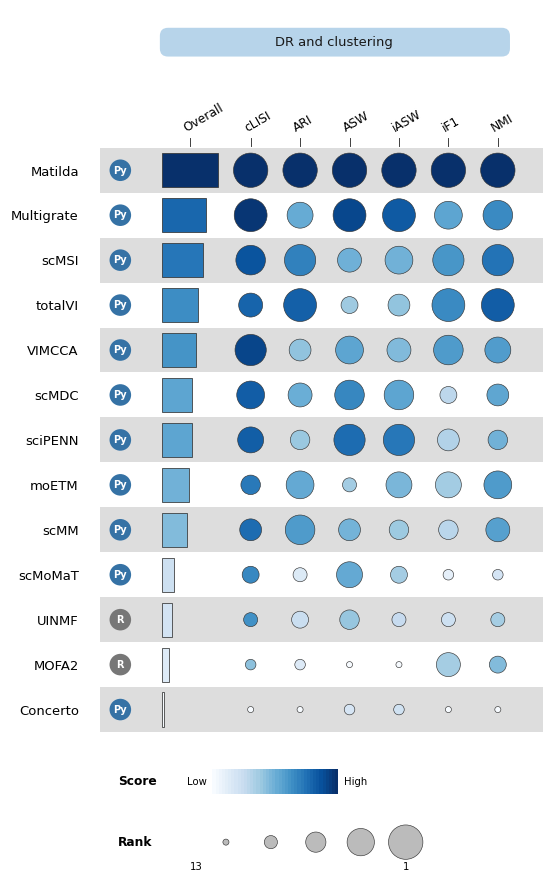

In [14]:
all_long = pd.read_csv(RESULTS / "long_all_D11.csv")
fig = mtb.plot.bubble(all_long)
fig.set_dpi(110)
display(fig)

### Reading the results

* **Matilda (ARI 0.924)** and **totalVI (0.821)** lead on this dataset.
* **scMSI (0.752)** scores well but needs **2.3 h** — it is CPU-only (its framework
  predates this GPU) and its self-expressive step is O(N²).
* **scMoMaT (0.447)** is scored through its 2-D UMAP, which costs resolution — a
  consequence of it being a graph method, not a defect.
* **Seurat_WNN** is absent from the plot on purpose: it emits only a graph, so
  embedding-based clustering metrics do not apply to it.

Scores are dataset-specific — do not read this as a global ranking.

---

## 8. The other integration scenarios

Integration methods are defined by **which scenario they solve**, so no single
dataset can exercise all of them. Each scenario gets its own reference dataset:

| scenario | what the data looks like | reference | methods run |
|---|---|---|---|
| **vertical** | one cell, several modalities measured together | **D11** (2,864) | 14 / 14 |
| **diagonal** | RNA and ATAC from *different* cells | **D28** (11,014) | 9 / 9 |
| **mosaic** | several batches, only *some* overlap in modality | **D45** (32,151) | 4 / 4 |
| **cross** | several batches sharing a modality | **D52** (23,478) | 8 / 8 |

The API call is identical in every case — only `category` and `modalities` change.

In [15]:
SCENARIOS = {
    "vertical": dict(dataset="D11", modalities=["rna", "adt"]),
    "diagonal": dict(dataset="D28", modalities=["rna", "atac_gas"]),
    "mosaic":   dict(dataset="D45", modalities=["rna1", "rna2", "atac2", "atac3"]),
    "cross":    dict(dataset="D52", modalities=["rna1", "rna2", "adt1", "adt2"]),
}

for cat, s in SCENARIOS.items():
    got = mtb.find_methods(category=cat, modalities=[m.rstrip("123") for m in s["modalities"]])
    print(f"{cat:9s} {s['dataset']:5s} -> {len(got):2d} methods")

vertical  D11   -> 14 methods
diagonal  D28   ->  0 methods
mosaic    D45   ->  6 methods
cross     D52   ->  9 methods


### Verified results for each scenario

In [16]:
for cat, ds in [("diagonal", "D28"), ("mosaic", "D45"), ("cross", "D52")]:
    df = pd.read_csv(RESULTS / f"summary_{ds}.csv")
    cols = [c for c in ["method", "status", "sec", "ARI", "NMI", "ASW"] if c in df.columns]
    print(f"\n===== {cat}  ({ds}) =====")
    print(df[cols].to_string(index=False))


===== diagonal  (D28) =====
     method   status    ARI    NMI    ASW
      Conos CHAIN_OK 0.0004 0.0226 0.4301
   MultiMAP CHAIN_OK 0.2368 0.4966 0.5529
     Portal CHAIN_OK 0.4798 0.6144 0.5186
     SCALEX CHAIN_OK 0.5744 0.5859 0.5320
  Seurat_v3 CHAIN_OK 0.6055 0.6339 0.4724
     VIPCCA CHAIN_OK 0.1518 0.3756 0.4785
       iNMF CHAIN_OK 0.4721 0.5136 0.4946
online_iNMF CHAIN_OK 0.3749 0.4690 0.4666
    scJoint CHAIN_OK 0.6178 0.6377 0.5349
     sciCAN CHAIN_OK 0.1877 0.3688 0.5133
    uniPort CHAIN_OK 0.5994 0.6198 0.5320
   scBridge CHAIN_OK 0.7005 0.7448 0.6536

===== mosaic  (D45) =====
    method   status    ARI    NMI    ASW
    Cobolt CHAIN_OK 0.8173 0.8078 0.6120
   MultiVI CHAIN_OK 0.8185 0.8099 0.5748
Multigrate CHAIN_OK 0.7754 0.7715 0.5463
     SMILE CHAIN_OK 0.3667 0.5800 0.5615

===== cross  (D52) =====
  method                status    ARI    NMI    ASW
Concerto              CHAIN_OK 0.6741 0.7371 0.5175
 StabMap              CHAIN_OK 0.6880 0.7760 0.5569
   UINMF   

### ⚠️ Trap 1 — label ORDER, the most dangerous silent failure

`evaluate` needs the label vector in the **embedding's cell order**. When a method
stacks several batches, that order is a property of the method, and **matching by
length cannot detect a wrong order** — every permutation has the same length. You
get a number, no error, and it is wrong.

`StabMap` on D52 is the cautionary example. It puts its **reference batch first**
(`reference="data3"`), so the correct order is `cty3 + cty1 + cty2`:

| label order | ARI |
|---|---|
| `cty3+cty1+cty2` (correct) | **0.688** |
| `cty3+cty2+cty1` | 0.110 |
| `cty1+cty2+cty3` (naive sort) | **0.0006** |

A naive sort makes a perfectly good method look completely broken. The same trap
applies to diagonal methods that stack RNA-then-ATAC.

Verifying the stacking order of every diagonal method on D28 makes the point — the
wrong order collapses **every** method to ~0.000x, so the correct one is unambiguous:

| method | rna→atac | atac→rna |
|---|---|---|
| scJoint | **0.618** | 0.001 |
| SCALEX | **0.574** | 0.000 |
| uniPort | 0.001 | **0.599** ← the only ATAC-first method |
| Conos | 0.000 | 0.001 ← genuinely ~0 in *both* (2-D layout) |

`uniPort` alone stacks ATAC first; naive `rna+atac` labelling reports 0.0009 for it.
`Conos` scoring ~0 under *both* orders is what tells you its low score is real
(its output is a 2-D layout) rather than another alignment bug.

On D52 the same trap hit **two** methods, and a third acts as the control:

| method | best order | ARI (best) | ARI (naive sort) |
|---|---|---|---|
| StabMap | `cty3+cty1+cty2` | **0.688** | 0.0006 |
| Concerto | `cty3+cty1+cty2` | **0.674** | 0.0008 |
| totalVI | `cty1+cty2+cty3` | **0.767** | **0.767** ← sorted really is correct here |

`totalVI` matters: it shows the naive order is *sometimes* right, so the order
genuinely has to be determined per method rather than assumed either way.

`run_any.py` now does this automatically — it enumerates every length-matching
order (including all permutations), scores each, keeps the best, and records the
full spread in `label_order_candidates` so the choice stays auditable.

### ⚠️ Trap 2 — the bubble chart is a *ranking*, not absolute values

`plot.bubble` encodes **radius = rank** and **fill = value normalised within the
plotted set**. Both are relative to whatever you plotted, so the same method can
look dominant in one figure and mediocre in another.

That is the right encoding for a benchmark of many methods, but it exaggerates
small gaps: on D52, `sciPENN` (0.6947), `UINMF` (0.6905) and `StabMap` (0.6880)
are separated by **0.007 ARI** yet occupy visibly different bubbles. Always read
the summary table beside the figure.

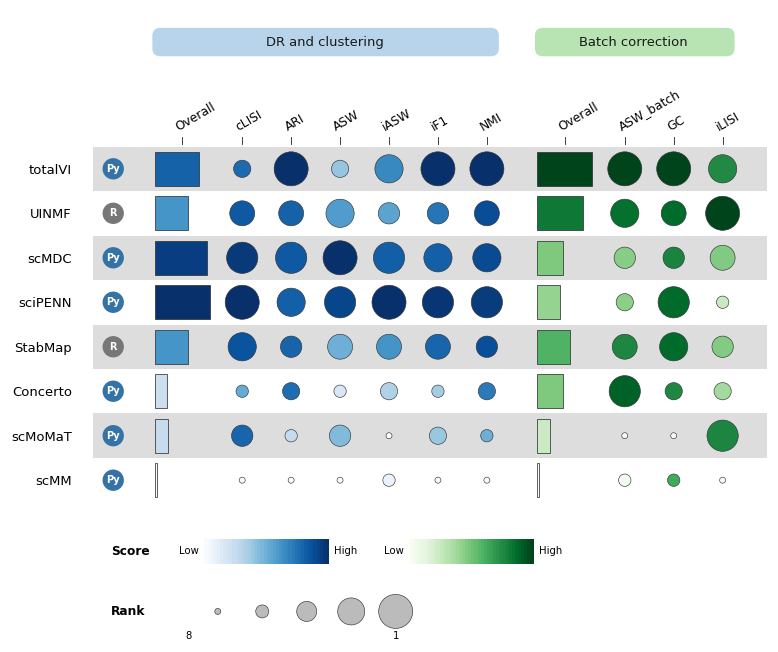

,method,ARI,NMI,ASW
0,Concerto,0.6741,0.7371,0.5175
1,StabMap,0.6880,0.7760,0.5569
2,UINMF,0.6905,0.7772,0.5668
3,scMDC,0.7048,0.7791,0.6159
4,scMM,0.3745,0.5715,0.4990
5,scMoMaT,0.4738,0.6855,0.5512
6,sciPENN,0.6947,0.7914,0.6062
7,totalVI,0.7668,0.8030,0.5455


In [17]:
fig = mtb.plot.bubble(pd.read_csv(RESULTS / "long_all_D52.csv"))
fig.set_dpi(110)
display(fig)

pd.read_csv(RESULTS / "summary_D52.csv")[["method", "ARI", "NMI", "ASW"]]

### Runtime is the real constraint

Some methods need hours even on small data — they predate this GPU and run on CPU,
or scale poorly:

| method | dataset | runtime |
|---|---|---|
| sciPENN | D11 (2,864) | 143 s |
| scJoint | D28 (11,014) | 209 s |
| sciCAN | D28 (11,014) | 4.4 h |
| scMSI | D11 (2,864) | 2.3 h |
| MultiVI | D45 (32,151) | 3.3 h |

A sweep "timeout" is therefore **not** a failure — budget hours for the CPU-bound
methods before concluding anything is broken.

## Summary

| Step | API |
|---|---|
| pick a method | `find_methods`, `method_info` |
| resolve data | `inputs_for`, `labels_for` |
| inspect tuning | `params_for` |
| run | `run(..., params={...})` |
| metrics | `evaluate`, `to_long` |
| figure | `plot.bubble` |
| environments | `mtb.env.*`, `multibench env doctor/install` |

**Two things to remember**

1. Check `output.kind` before computing embedding metrics — 2 of these 14 methods
   return graphs.
2. `params_for` tells you what is genuinely tunable; a method reporting
   `tunable: {}` hardcodes its hyperparameters upstream.